### **Exploratory Data Analysis (EDA)**
Loads the raw dataset and explores distributions, missing values, and relationships between features.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [25]:
# importing the dataset
df = pd.read_csv('/content/drive/MyDrive/DS & ML/diabetic_data.csv')

In [26]:
#loading the fist 10 rows of the dataset
df.head(10)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [27]:
df.tail()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),?,1,1,7,6,...,No,No,No,No,No,No,No,No,No,NO


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [29]:
df.shape

(101766, 50)

In [30]:
numerical_summary = df.describe()
numerical_summary

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [31]:
categorical_summary = df.describe(include=['O'])
categorical_summary

,race,gender,age,weight,payer_code,medical_specialty,diag_1,diag_2,diag_3,max_glu_serum,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,101766,101766,101766,101766,101766,101766,101766,101766,101766,5346,...,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,6,3,10,10,18,73,717,749,790,3,...,1,4,4,2,2,2,2,2,2,3
top,Caucasian,Female,[70-80),?,?,?,428,276,250,Norm,...,No,No,No,No,No,No,No,No,Yes,NO
freq,76099,54708,26068,98569,40256,49949,6862,6752,11555,2597,...,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864


In [32]:
df['gender'].unique()

array(['Female', 'Male', 'Unknown/Invalid'], dtype=object)

In [33]:
# replacing invalid values
df.replace(('?','Unknown/Invalid'), np.nan, inplace=True)

# Check for missing values
missing_values = df.isnull().sum()
print(missing_values)

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          3
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

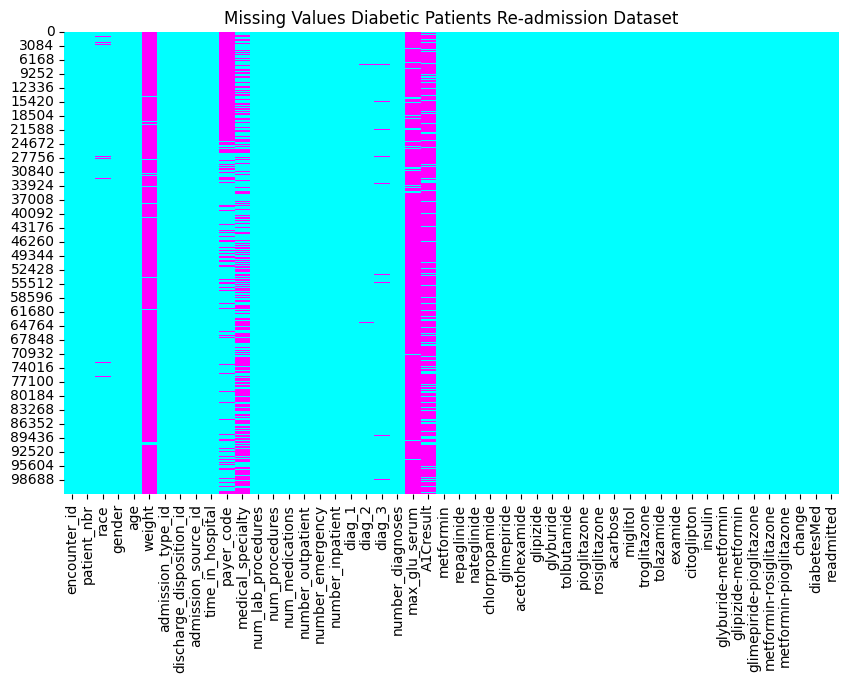

In [34]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='cool')
plt.title('Missing Values Diabetic Patients Re-admission Dataset')
plt.show()

In [35]:
#checking for duplicates
df[df.duplicated]

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted


In [36]:
df['weight'].unique()

array([nan, '[75-100)', '[50-75)', '[0-25)', '[100-125)', '[25-50)',
       '[125-150)', '[175-200)', '[150-175)', '>200'], dtype=object)

In [37]:
df['payer_code'].unique()

array([nan, 'MC', 'MD', 'HM', 'UN', 'BC', 'SP', 'CP', 'SI', 'DM', 'CM',
       'CH', 'PO', 'WC', 'OT', 'OG', 'MP', 'FR'], dtype=object)

In [38]:
# Target variable distribution
df['readmitted'].value_counts()

,count
readmitted,
NO,54864
>30,35545
<30,11357


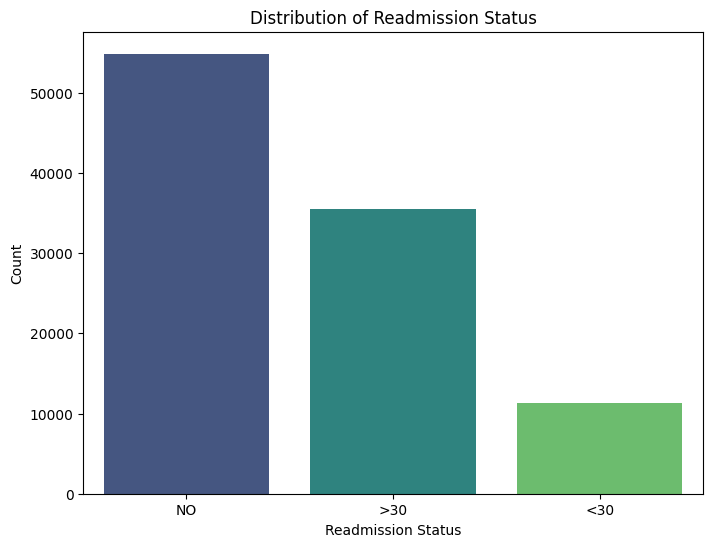

In [39]:
# Target Class distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='readmitted', palette='viridis')
plt.title('Distribution of Readmission Status')
plt.xlabel('Readmission Status')
plt.ylabel('Count')
plt.show()

**Insight:** The chart shows that the majority of patients were not readmitted (NO). A significant number were readmitted after 30 days (>30), and the smallest group consists of patients readmitted within 30 days (<30).

This distribution is crucial for understanding the target variable and evaluating the challenge of predicting early readmissions.

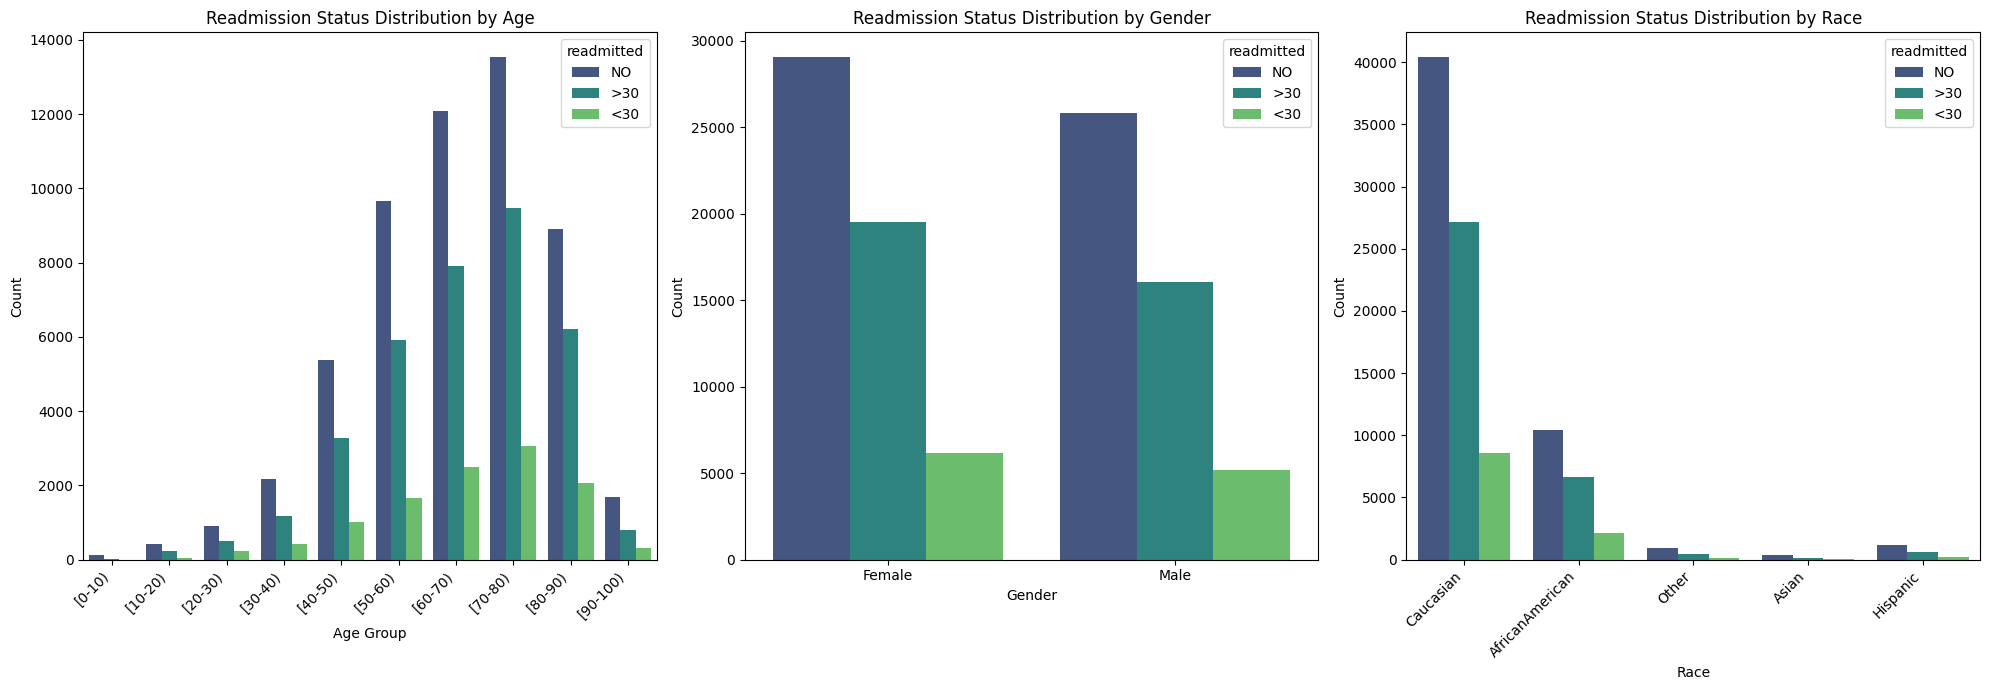

In [40]:
# plots for readmission status distribution by age, gender, and race
plt.figure(figsize=(20, 7))

# Readmission status distribution by Age
plt.subplot(1, 3, 1)
sns.countplot(data=df, x='age', hue='readmitted', palette='viridis')
plt.title('Readmission Status Distribution by Age')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate for better readability

# Readmission status distribution by Gender
plt.subplot(1, 3, 2)
sns.countplot(data=df, x='gender', hue='readmitted', palette='viridis')
plt.title('Readmission Status Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

# Readmission status distribution by Race
plt.subplot(1, 3, 3)
sns.countplot(data=df, x='race', hue='readmitted', palette='viridis')
plt.title('Readmission Status Distribution by Race')
plt.xlabel('Race')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate for better readability

plt.tight_layout()
plt.show()

* **Readmission Status Distribution by Age:** The plot shows that older age groups, particularly those in the [70-80) and [60-70) ranges, have a higher overall count of patients, and also a higher count across all readmission categories (NO, >30, <30).
This suggests that age is a significant factor in patient hospitalizations and readmissions, with older patients potentially being more prone to readmission.

* **Readmission Status Distribution by Gender:** This plot illustrates the readmission status based on gender. The dataset contains more female patients overall, leading to a higher number of female patients in all readmission categories (NO, >30, <30) compared to male patients. The proportion of readmissions within each gender group appears to be similar.

* **Readmission Status Distribution by Race:** The plot displays the readmission status across different racial groups. Caucasian patients represent the largest group and consequently show the highest absolute numbers across all readmission categories. African American patients also have a substantial number of readmissions.

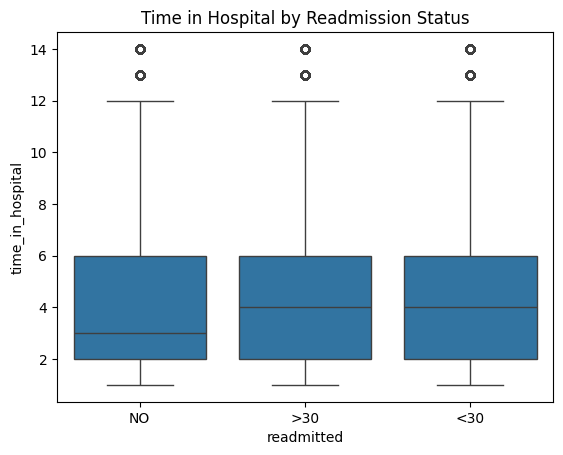

In [41]:
# Do readmitted patients stay longer in the hospital?
sns.boxplot(x='readmitted', y='time_in_hospital', data=df)
plt.title('Time in Hospital by Readmission Status')
plt.show()

**Insight:** Patients who were readmitted within 30 days (<30) tend to have a slightly 'shorter' median hospital stay compared to those not readmitted (NO) or readmitted after 30 days (>30).

This might suggest that patients with shorter initial stays could be at higher risk for quick readmission, possibly due to insufficient recovery time or unresolved underlying issues.

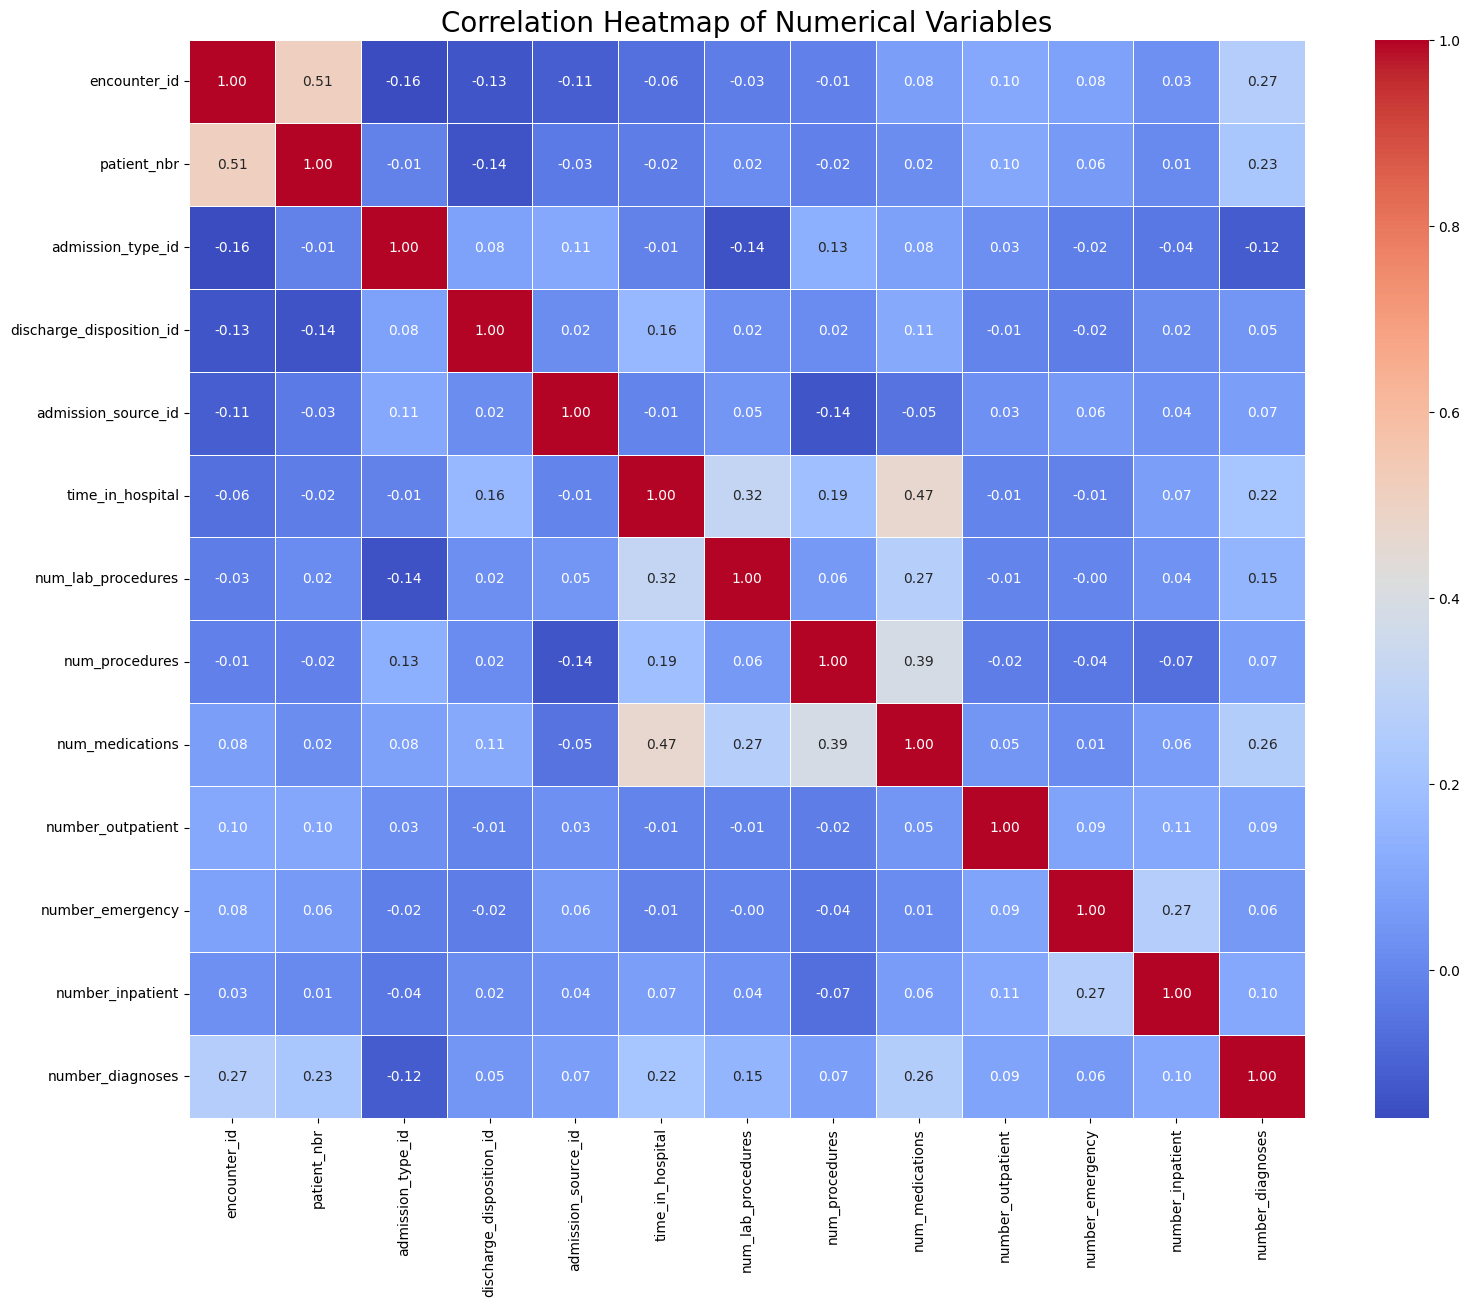

In [42]:
# Select only numerical columns for correlation calculation
numerical_cols = df.select_dtypes(include=np.number).columns

# Calculate the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Set up the matplotlib figure
plt.figure(figsize=(18, 14))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Variables', fontsize=20)
plt.show()

**Insight:** This visualization helps identify strong relationships between numerical features. For example,

* 'num_lab_procedures' shows a moderate positive correlation with 'time_in_hospital', suggesting that patients with longer hospital stays tend to undergo more lab procedures
* 'num_lab_procedures' and 'num_medications': These two also show a moderate positive correlation suggesting that patients who undergo more lab procedures also tend to be on a higher number of medications.
* 'time_in_hospital' and 'num_medications': These two exhibit a strong positive correlation indicating that as the time a patient spends in the hospital increases, the number of medications they are on also significantly increases.
* 'number_inpatient' and 'number_diagnoses': There is a moderate positive correlation (around 0.26), suggesting that patients with a higher number of prior inpatient visits tend to have more diagnoses.

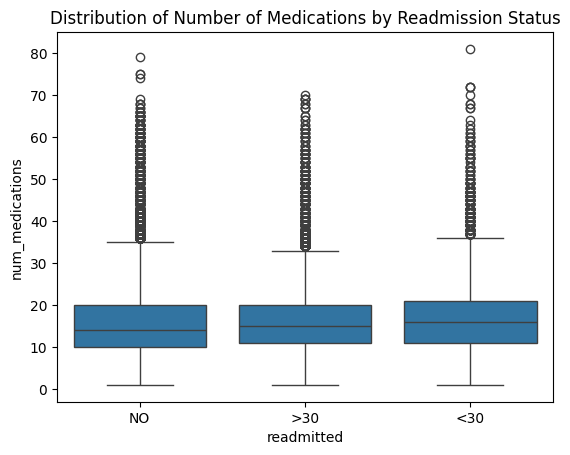

In [43]:
# do readmitted patients take more medication?
sns.boxplot(x='readmitted', y='num_medications', data=df)
plt.title('Distribution of Number of Medications by Readmission Status')
plt.show()

**Insight:** Patients who are readmitted within 30 days (<30) tend to have a slightly higher median and overall distribution of medication counts compared to those not readmitted (NO) or readmitted after 30 days (>30).

This suggests that a higher number of medications might be associated with a quicker readmission, possibly indicating more complex health conditions or treatment regimens.